# Time Series Forecasting with LSTM and SUMO data

## Project Overview

This work aims to demonstrate how we can use a dataset created with the SUMO Simulator to train an LSTM (Long Short-Term Memory) model to forecast vehicle speeds. The project involves building and training a basic LSTM model to predict average vehicle speeds based on historical data.

## Dataset Description

The dataset contains the following columns:
- **timestep_time**: The time at each timestep.
- **vehicle_angle**: The angle of the vehicle.
- **vehicle_id**: Unique identifier for each vehicle.
- **vehicle_lane**: The lane in which the vehicle is traveling.
- **vehicle_pos**: The position of the vehicle.
- **vehicle_slope**: The slope of the vehicle's movement.
- **vehicle_speed**: The speed of the vehicle.
- **vehicle_type**: The type of the vehicle (e.g., passenger, truck).
- **vehicle_x**: The x-coordinate of the vehicle.
- **vehicle_y**: The y-coordinate of the vehicle.

The key column for this project is **vehicle_speed**, which will be used as the target variable for the LSTM model. The other columns provide contextual information that could be used as features for training the model.

The dataset was generated from a simulation of a car-only network in Athens, Greece, using the OSMWebWizard with the default settings for the area. The simulation covers a duration of 2 hours, with data collected at each timestep. This dataset is derived from the Floating Car Data (FCD) output of the SUMO Simulator.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# load the data
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/My Drive/output_fcd.csv', sep=';')

# print the head
print(data.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   timestep_time  vehicle_angle vehicle_id  vehicle_lane  vehicle_pos  \
0            0.0         229.42       veh0  24913519#0_2         5.10   
1            1.0         229.12       veh0  24913519#0_2         7.20   
2            2.0         228.82       veh0  24913519#0_2        10.91   
3            3.0         228.82       veh0  24913519#0_2        16.97   
4            4.0         228.82       veh0  24913519#0_2        25.29   

   vehicle_slope  vehicle_speed   vehicle_type  vehicle_x  vehicle_y  
0            0.0           0.00  veh_passenger    1041.41     377.58  
1            0.0           2.10  veh_passenger    1039.83     376.21  
2            0.0           3.71  veh_passenger    1037.04     373.76  
3            0.0           6.06  veh_passenger    1032.48     369.78  
4            0.0           8.32  veh_passenger    1026.22     364.30  


In [ ]:
average_speed_per_timestep = data.groupby('timestep_time')['vehicle_speed'].mean().reset_index()
average_speed_per_timestep.columns = ['timestep_time', 'average_vehicle_speed']
average_speed_per_timestep = average_speed_per_timestep.sort_values('timestep_time')
print(average_speed_per_timestep.head())

   timestep_time  average_vehicle_speed
0            0.0                   0.00
1            1.0                   2.10
2            2.0                   3.71
3            3.0                   6.06
4            4.0                   8.32


In [ ]:
# Normalize the data
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(average_speed_per_timestep['average_vehicle_speed'].values.reshape(-1, 1))

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30
X, y = create_sequences(data_normalized, seq_length)

In [ ]:

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

# Predict using the model
predictions = model.predict(X_val)
predictions = scaler.inverse_transform(predictions)

# Evaluate the model
mse = model.evaluate(X_val, y_val)
print(f'Mean Squared Error: {mse}')

Epoch 1/20
180/180 [==============================] - 10s 30ms/step - loss: 0.0156 - val_loss: 0.0077
Epoch 2/20
180/180 [==============================] - 7s 41ms/step - loss: 0.0066 - val_loss: 0.0071
Epoch 3/20
180/180 [==============================] - 6s 32ms/step - loss: 0.0051 - val_loss: 0.0046
Epoch 4/20
180/180 [==============================] - 5s 26ms/step - loss: 0.0038 - val_loss: 0.0034
Epoch 5/20
180/180 [==============================] - 6s 34ms/step - loss: 0.0030 - val_loss: 0.0024
Epoch 6/20
180/180 [==============================] - 5s 28ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 7/20
180/180 [==============================] - 5s 26ms/step - loss: 0.0022 - val_loss: 0.0036
Epoch 8/20
180/180 [==============================] - 6s 36ms/step - loss: 0.0019 - val_loss: 0.0024
Epoch 9/20
180/180 [==============================] - 5s 26ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 10/20
180/180 [==============================] - 5s 25ms/step - loss: 0.0017 - val_l

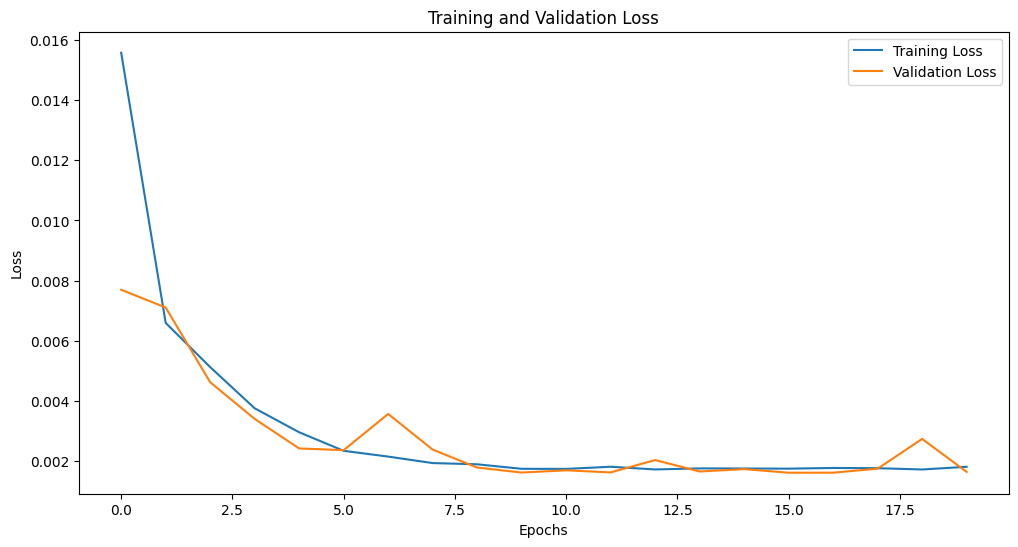

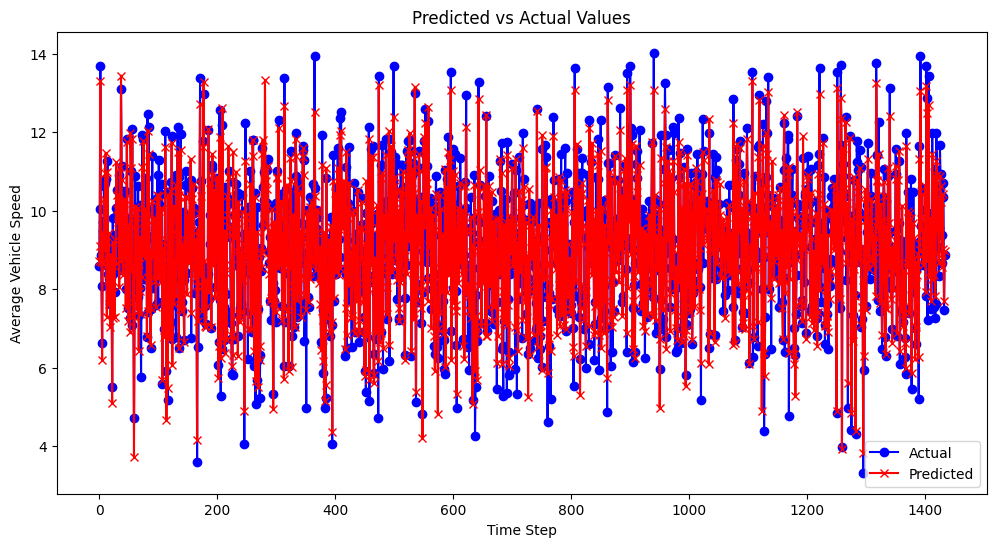

In [ ]:

# Plot the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot the predicted vs actual values
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_val)), scaler.inverse_transform(y_val), marker='o', linestyle='-', color='b', label='Actual')
plt.plot(range(len(predictions)), predictions, marker='x', linestyle='-', color='r', label='Predicted')
plt.title('Predicted vs Actual Values')
plt.xlabel('Time Step')
plt.ylabel('Average Vehicle Speed')
plt.legend()
plt.show()


In [ ]:
# Split the data into training and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Predict using the model
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Evaluate the model
mse = model.evaluate(X_test, y_test)
print(f'Mean Squared Error: {mse}')


Epoch 1/20
180/180 [==============================] - 11s 41ms/step - loss: 0.0170 - val_loss: 0.0084
Epoch 2/20
180/180 [==============================] - 5s 25ms/step - loss: 0.0070 - val_loss: 0.0066
Epoch 3/20
180/180 [==============================] - 5s 30ms/step - loss: 0.0054 - val_loss: 0.0047
Epoch 4/20
180/180 [==============================] - 6s 32ms/step - loss: 0.0038 - val_loss: 0.0032
Epoch 5/20
180/180 [==============================] - 5s 25ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 6/20
180/180 [==============================] - 6s 32ms/step - loss: 0.0021 - val_loss: 0.0019
Epoch 7/20
180/180 [==============================] - 5s 30ms/step - loss: 0.0019 - val_loss: 0.0025
Epoch 8/20
180/180 [==============================] - 5s 25ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 9/20
180/180 [==============================] - 6s 34ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 10/20
180/180 [==============================] - 5s 28ms/step - loss: 0.0018 - val_l

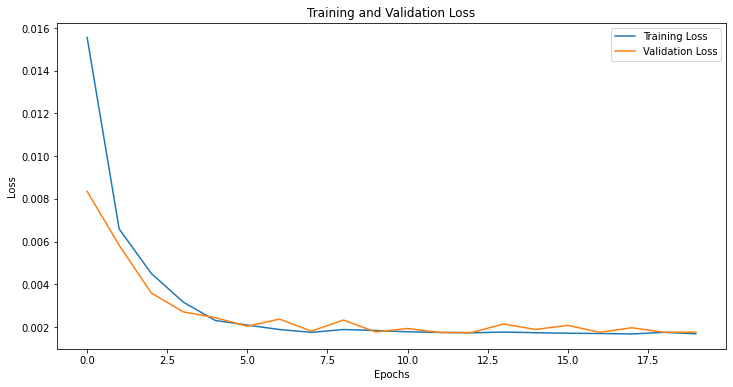

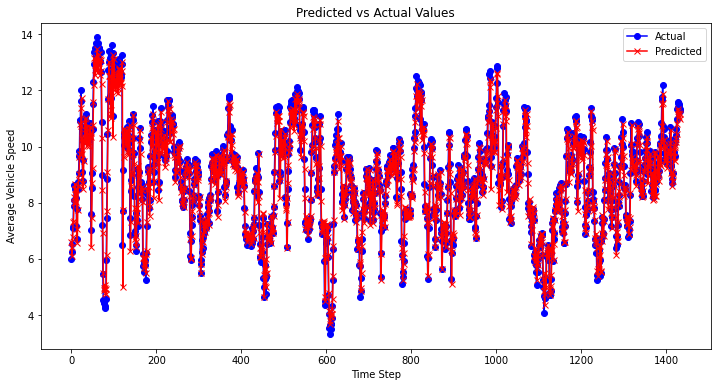

In [ ]:

# Plot the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot the predicted vs actual values
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), scaler.inverse_transform(y_test.reshape(-1, 1)), marker='o', linestyle='-', color='b', label='Actual')
plt.plot(range(len(predictions)), predictions, marker='x', linestyle='-', color='r', label='Predicted')
plt.title('Predicted vs Actual Values')
plt.xlabel('Time Step')
plt.ylabel('Average Vehicle Speed')
plt.legend()
plt.show()


## Summary

This project demonstrates the successful application of LSTM for time series forecasting of average vehicle speeds on data generated with SUMO. The model generalizes well to new, unseen data, as evidenced by the close alignment of training and validation losses and the accurate predictions on the test set.


